# Fraud Detection: EDA
Source: `creditcard.csv` (Kaggle mlg-ulb/creditcardfraud) — 284,807 transactions,
492 confirmed frauds (0.173%), `V1`-`V28` PCA-anonymized features, `Time`, `Amount`.

Day 1 findings feeding into this notebook:
- 1,081 duplicate rows (19 fraud) — dropped here BEFORE any analysis or split,
  to avoid leakage downstream.
- Fraud mean ($122) > legit mean ($88), but fraud median ($9.25) < legit
  median ($22) — worth investigating whether fraud is actually two
  populations (small "card testing" + a large-amount tail).

**Goal:** find which features actually separate fraud from legit, and
whether time-of-day / amount patterns are real signal or noise.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.width', 120)
csv_path = Path('../data/raw/creditcard.csv')
df = pd.read_csv(csv_path)
print("Raw shape:", df.shape)

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows -> {df.shape}")


Raw shape: (284807, 31)
Dropped 1081 duplicate rows -> (283726, 31)


## Amount: is fraud really two populations?

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87

Fraud transactions under $5: 44.4%
Legit transactions under $5: 23.6%


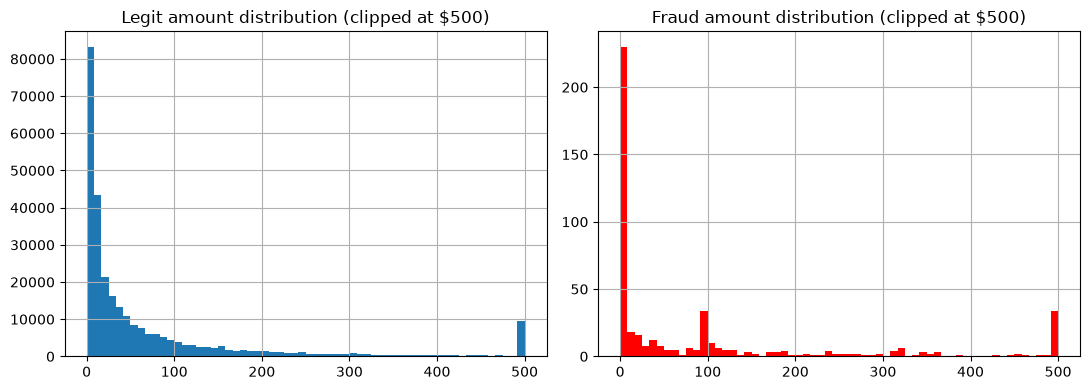

In [2]:
print(df.groupby('Class')['Amount'].describe())

small_fraud_pct = (df[df['Class']==1]['Amount'] < 5).mean()
small_legit_pct = (df[df['Class']==0]['Amount'] < 5).mean()
print(f"\nFraud transactions under $5: {small_fraud_pct:.1%}")
print(f"Legit transactions under $5: {small_legit_pct:.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11,4))
df[df['Class']==0]['Amount'].clip(upper=500).hist(bins=60, ax=ax[0])
ax[0].set_title('Legit amount distribution (clipped at $500)')
df[df['Class']==1]['Amount'].clip(upper=500).hist(bins=60, ax=ax[1], color='red')
ax[1].set_title('Fraud amount distribution (clipped at $500)')
plt.tight_layout(); plt.show()


**Interpretation space (fill in with your real numbers):** if fraud has a
meaningfully higher rate of very-small transactions than legit, that
supports the card-testing theory — attackers verify a stolen card works
with a tiny charge before a larger one. Note it here either way; don't
assume the theory is confirmed just because the means/medians diverged.

## Time-of-day pattern

hour_of_day
0.0     0.000785
1.0     0.002376
2.0     0.014510
3.0     0.004875
4.0     0.010436
5.0     0.003681
6.0     0.002205
7.0     0.003180
8.0     0.000880
9.0     0.001015
10.0    0.000483
11.0    0.003158
12.0    0.001105
13.0    0.001109
14.0    0.001392
15.0    0.001588
16.0    0.001342
17.0    0.001736
18.0    0.001651
19.0    0.001221
20.0    0.001078
21.0    0.000908
22.0    0.000585
23.0    0.001562
Name: Class, dtype: float64


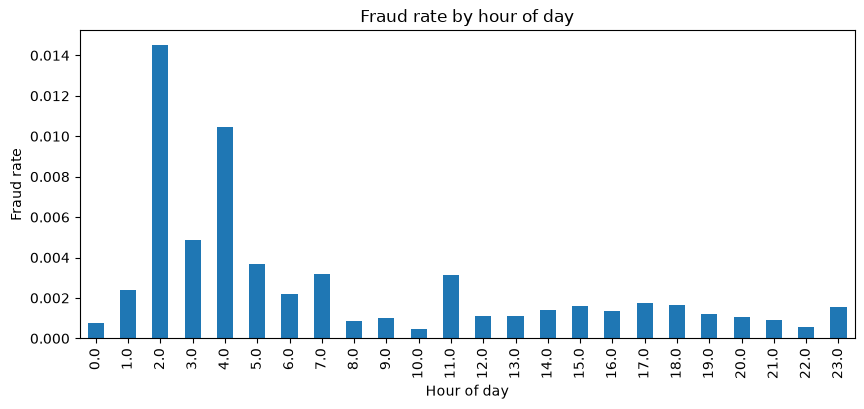

In [3]:
df['hour_of_day'] = (df['Time'] % 86400) // 3600

hourly_fraud_rate = df.groupby('hour_of_day')['Class'].mean()
print(hourly_fraud_rate)

hourly_fraud_rate.plot(kind='bar', figsize=(10,4),
                        title='Fraud rate by hour of day')
plt.ylabel('Fraud rate'); plt.xlabel('Hour of day'); plt.show()


**Caveat:** `Time` is seconds elapsed since the first transaction in the
dataset, not a real clock time — hour 0 doesn't necessarily mean midnight.
Treat this as "hours since data collection started, mod 24" not "actual
local hour." Still useful for spotting a cyclical pattern, just don't
over-claim what it represents in the README.

## Which V1-V28 features actually separate fraud from legit?

Top 10 features by |correlation| with Class:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


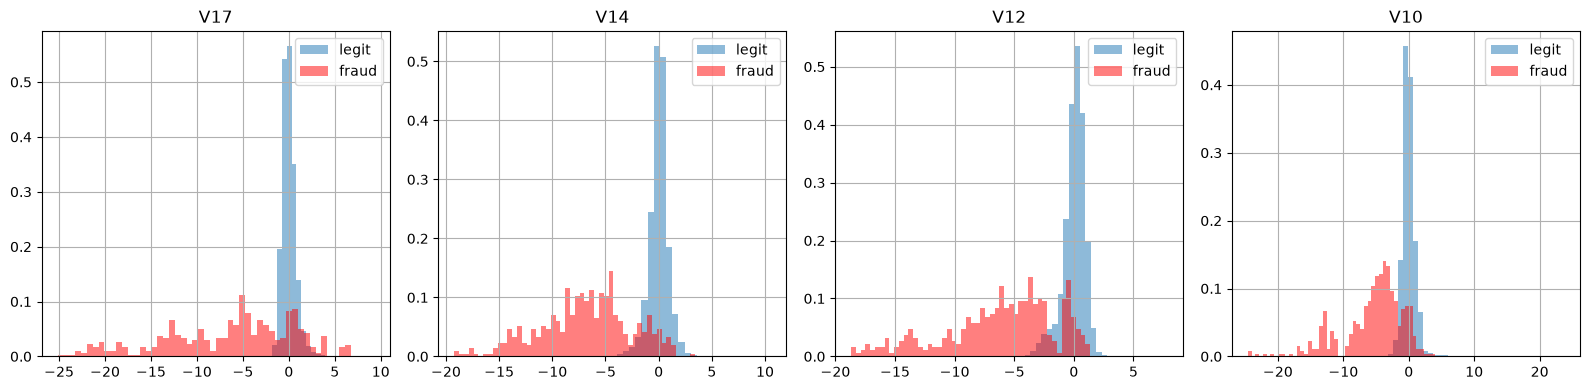

In [4]:
corr = df.corr(numeric_only=True)['Class'].drop('Class').abs().sort_values(ascending=False)
print("Top 10 features by |correlation| with Class:")
print(corr.head(10))

top_features = corr.head(4).index.tolist()
fig, axes = plt.subplots(1, len(top_features), figsize=(16,4))
for ax, feat in zip(axes, top_features):
    df[df['Class']==0][feat].hist(bins=50, ax=ax, alpha=0.5, label='legit', density=True)
    df[df['Class']==1][feat].hist(bins=50, ax=ax, alpha=0.5, label='fraud', density=True, color='red')
    ax.set_title(feat); ax.legend()
plt.tight_layout(); plt.show()


## Correlation among the top features (check for redundancy)

In [5]:
top10 = corr.head(10).index.tolist()
print(df[top10].corr().round(2))


      V17   V14   V12   V10   V16    V3    V7   V11   V4   V18
V17  1.00 -0.01 -0.01 -0.01 -0.01 -0.01 -0.01  0.01  0.0 -0.01
V14 -0.01  1.00 -0.01  0.00 -0.01 -0.00 -0.00  0.01  0.0 -0.00
V12 -0.01 -0.01  1.00 -0.01 -0.01 -0.01 -0.01  0.01  0.0 -0.00
V10 -0.01  0.00 -0.01  1.00 -0.00 -0.01 -0.01  0.00  0.0 -0.00
V16 -0.01 -0.01 -0.01 -0.00  1.00 -0.00 -0.01  0.00  0.0 -0.01
V3  -0.01 -0.00 -0.01 -0.01 -0.00  1.00 -0.01  0.00  0.0 -0.00
V7  -0.01 -0.00 -0.01 -0.01 -0.01 -0.01  1.00  0.00  0.0 -0.00
V11  0.01  0.01  0.01  0.00  0.00  0.00  0.00  1.00 -0.0  0.00
V4   0.00  0.00  0.00  0.00  0.00  0.00  0.00 -0.00  1.0  0.00
V18 -0.01 -0.00 -0.00 -0.00 -0.01 -0.00 -0.00  0.00  0.0  1.00
